**Chosen dataset: https://universe.roboflow.com/morningsun/rsod-kmnr1**

It is designed for object detection in satellite images.

It contains 872 images and 4 classes: aircraft, oiltank, playground, overpass.

Images number in train: 608
Images number in valid: 177
Images number in test: 87


[train]
Class 'aircraft' has: 3183 objects
Class 'oiltank' has: 1133 objects
Class 'overpass' has: 127 objects
Class 'playground' has: 115 objects

[valid]
Class 'aircraft' has: 915 objects
Class 'oiltank' has: 350 objects
Class 'overpass' has: 39 objects
Class 'playground' has: 27 objects

[test]
Class 'aircraft' has: 457 objects
Class 'oiltank' has: 215 objects
Class 'overpass' has: 12 objects
Class 'playground' has: 8 objects


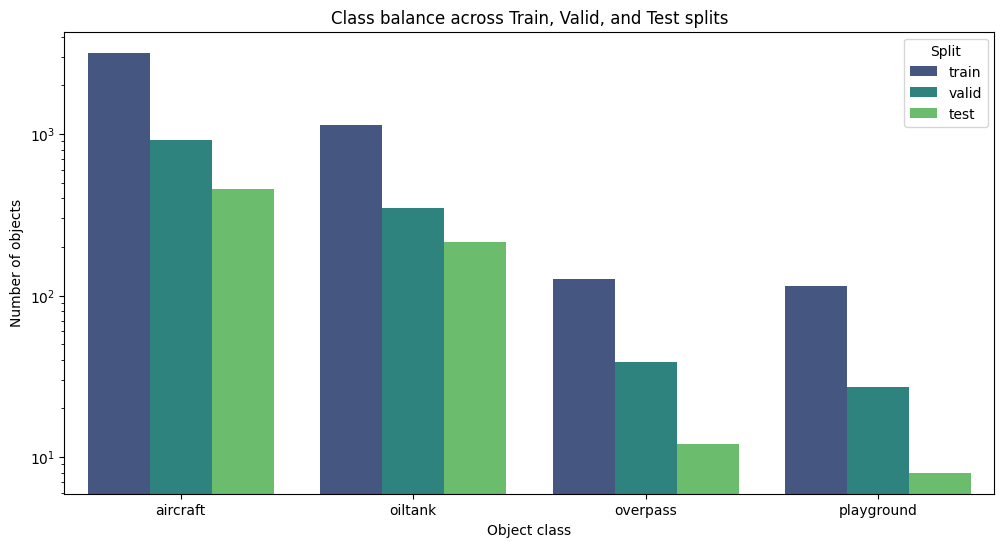

In [ ]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = '../content/drive/MyDrive/RSOD-dataset'

splits = ['train', 'valid', 'test']
for split in splits:
    img_dir = os.path.join(dataset_path, split, 'images')
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"Images number in {split}: {count}")

print()
with open(os.path.join(dataset_path, 'data.yaml'), 'r') as f:
    classes = yaml.safe_load(f)['names']

data = []

for split in splits:
    labels_dir = os.path.join(dataset_path, split, 'labels')
    if not os.path.exists(labels_dir):
        continue

    class_counts = {name: 0 for name in classes}

    for label_file in os.listdir(labels_dir):
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f.readlines():
                class_id = int(line.split()[0])
                class_counts[classes[class_id]] += 1

    print(f"\n[{split}]")
    for name, count in class_counts.items():
        data.append({'Split': split, 'Class': name, 'Count': count})
        print(f"Class '{name}' has: {count} objects")

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Class', y='Count', hue='Split', palette='viridis')
plt.title('Class balance across Train, Valid, and Test splits')
plt.xlabel('Object class')
plt.ylabel('Number of objects')
plt.yscale('log')
plt.show()

# **Dataset observation:**

The dataset is split into train (608), valid (177), and test (87) images, strictly following the standard of 70%/20%/10% ratio. More importantly, the severe class imbalance (distribution dominated by aircraft and oiltank) is consistently stratified across all three splits, ensuring objective validation and testing.

---

All images are 640x640 pixels. This is highly beneficial as it matches the default input size (imgsz=640) of YOLOv8, preventing any aspect of artifacts during the preprocessing stage.

---

Visual inspection confirms that bounding boxes are placed accurately. Notably, dense clusters of objects (for example oiltank farms) are labeled individually rather than being grouped under a single massive bounding box, which is crucial for training an object detector. No obviously missing labels were detected in the reviewed samples.

---

The dataset contains strictly single-class images (for example an image contains only aircraft or only overpasses), but since YOLOv8 has a Mosaic Augmentation (which stitches 4 random images together during training), there will be no problems with that.

---

The dataset contains "Google earth" watermark, along with occasional UI elements (such as a Windows 7 taskbar). Because these artifacts are uniformly distributed across all images and classes, the YOLOv8 model is expected to treat them as background noise. However, it's recommended to get rid of these artifacts.

In [9]:
# check gpu usage
!nvidia-smi

Thu Feb 26 17:13:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             32W /   70W |    6719MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

In [25]:
model = YOLO('yolov8n.pt')

In [ ]:
test_prediction = model.predict(source="https://www.ultralytics.com/images/bus.jpg", conf=0.25)

In [19]:
results = model.train(
    data='../content/drive/MyDrive/RSOD-dataset/data.yaml',
    epochs=150,
    imgsz=640,
    batch=32,
    patience=50,
    project='visicom_test',
    name='rsod_yolov8n'
)

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../content/drive/MyDrive/RSOD-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rsod_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

**Batch=32**

The batch size was chosen to maximize the VRAM usage on the Google Colab GPU (Tesla T4) without causing Out-of-Memory. During initial testing, the YOLO AutoBatch feature (batch=-1) suggested values around 29–31. To ensure optimal hardware utilization, this value was rounded up to the standard batch=32.

**Epochs=150, Patience=50**

The maximum number of epochs was set to 150. This is the optimal range for Transfer Learning on a small dataset using a lightweight model like YOLOv8n, ensuring the model has enough time to learn without wasting Colab's strict time limits. To prevent resource waste and overfitting, patience=50 was used as a safety net. This guarantees that training would stop automatically if the model stopped improving for 50 consecutive epochs.

**Precision (0.936)**

It means how many objects were actually correct out of all the objects the model highlighted.

A high precision of 93.6% means the model has a very low rate of False Positives. For example, it rarely mistakes background objects for target.

As seen in the training graphs, Precision grew rapidly during the first 50 epochs, reaching about 90%. After that, it stabilized and maintained a consistently high level until epoch 150.

**Recall (0.910)**

It means how many objects model found out of all the real objects that actually exist in the images.

A recall of 91.0% means the model has a very low rate of missed objects (False Negatives). It successfully detects almost all targets without skipping them.

Recall showed a very fast increase in the first 30-40 epochs, quickly climbing to around 90%. Afterward, it plateaued and remained very stable through the rest of the training process.

**mAP50 (0.934)**

It means the overall quality score of the model.
This combines both Precision and Recall into a single grade. The "50" means a detection is considered correct if the model's box overlaps the real object by at least 50%.

A score of 93.4% proves the model works well.

Similar to Precision and Recall, mAP50 experienced a climb during the first 50 epochs. After crossing the 90% mark, it stabilized.

**mAP50-95 (0.707)**

It means how accurate the box borders are drawn.

It tests the model at much higher overlap requirements from 50% up to 95%. A good score here means the model doesn't just find the object, but draws the box around it very accurately.

Unlike the other metrics that plateaued early, mAP50-95 shows a steady, continuous climb throughout the entire 150 epochs. This proves that even late in the training process, the model was still actively learning to draw closer bounding boxes around the objects.

In [ ]:
# test model on the test data and save results
# as every image in the dataset contins only 1 class of objects it means that whenever the model detects several classes in 1 image it's 100% failed
import os
import cv2

model_path = '../content/drive/MyDrive/rsod_yolov8n/weights/best.pt'
model = YOLO(model_path)

test_images_dir = '../content/drive/MyDrive/RSOD-dataset/test/images'

all_test_images = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.endswith('.jpg')]

success_dir = '../content/drive/MyDrive/succeeded_tests'
fail_dir = '../content/drive/MyDrive/failed_tests'
os.makedirs(success_dir, exist_ok=True)
os.makedirs(fail_dir, exist_ok=True)

for img_path in all_test_images:
    results = model.predict(img_path, conf=0.25, verbose=False)

    annotated_img = results[0].plot()

    detected_classes = set(results[0].boxes.cls.tolist())

    if len(detected_classes) > 1:
        save_dir = fail_dir
    else:
        save_dir = success_dir

    img_name = os.path.basename(img_path)
    save_path = os.path.join(save_dir, f"pred_{img_name}")
    cv2.imwrite(save_path, annotated_img)

print(f"\nAll {len(all_test_images)} predictions are saved.")

# **Inference**

**Why I chose this dataset**

The most important reason is that the dataset matches Visicom's area of work. The objects in the images represent type of real-world mapping and tasks the company deals with.

The dataset contains 872 images. This is an ideal size for training a small model, as the recommended range is usually between 500 and 2,000 images.

The dataset author provided a standard and highly effective data split: 70% for training, 20% for validation, and 10% for testing. Moreover, the dataset has an even balance of classes across most categories, which helps the model learn.

**What went well**

The training process was successful. The model achieved overall accuracy (93.4% mAP50 score).

It reliably detects the main objects with very few false alarms, proving that the model learned the core patterns well.

**Where the model fails and why**

The model sometimes struggles to correctly detect "playgrounds" and "overpasses".

The reason is that there were simply not enough examples of these two specific classes in the dataset. Because the model saw them much less often during training, it did not learn to recognize them as confidently as the others.

**What I would change if I had more time**

To fix the lack of images for those rare classes, I would find and add more images specifically containing playgrounds and overpasses. I would Also use techniques like rotation, zooming, or color shifting on the existing images.